# **Coastal Water Temperature Final Station Graphics**

Last updated on: 6/9/2026

## Overview
NOAA's CO-OPS collects trusted coastal data—including water temperature, tides, and currents—that helps keep navigation safe, supports commerce, and protects coastal communities and ecosystems. Since the early 1990s, over 220 water temperature sensors have been installed along U.S. coasts and in the Great Lakes. CO-OPS did an in-depth analysis on 174 stations with at least 20 years of data. An automated quality control system was developed to streamline data processing, flagging suspect data, and calculating daily averages. Manual reviews also caught sensor drifts at 47 stations, ensuring the data is reliable for long-term research. 

## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**. To work offline, manage libraries and dependencies personally; using **Jupyter Notebook** is recommended. If you want cloud-based instant access, seamless co-operation and have access to good internet connection, **Google Colab** is the best option.

This notebook is designed so that people with limited familiarity with Python can run the notebook. To do so, go to the [github](https://github.com/NOAA-CO-OPS/coastal-water-temperature) page and click on the drop down menu under 'Code', then download the ZIP file. Extract the ZIP file and upload the Coastal_temp_final_station_graphics into [google colab](https://colab.research.google.com/). [Explore different station/s](https://tidesandcurrents.noaa.gov) and change the station variable in step 3. There is also an option to run through all of the station. The code creates a folder called "Daily_Water_Final_Plots" in your working directory for storing the created graphics. Lastly, click **Runtime** in the top menu and choose **Run All**. Then, when the 'Choose Files' box in step 2 becomes active, click on it and upload the Daily_Water_flagged_dates.zip and station_region_list. You will see a green check mark to the left of each cell as cells are sucessfully executed.

Users should be prepared to commit 30 minutes to familiarize themselves with the notebook, upload data, run code and examine results.

## Learning Outcomes
In this notebook users will be able to:
  1. Explore daily averaged water temperature data at over 100 stations
  2. Plot and save different figures that represent each stations including a time series plot, a residual plot, an average seasonal cycle plot, a seasonal cycle over the years plot, and a heatmap.

## Data Sources and Documentation

All data comes from CO-OPS's sensors. Stations with water temperature data can be found via [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations.json?type=watertemp). 6-min water temperature data can be accessed through [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/).

The QA/QC’d daily water temperature data used in this notebook is available on GitHub. Each station's data is provided as a separate comma-separated values (CSV) file containing daily means, residuals, and quality control (QC) flags.

  Each CSV file includes the following columns:

  - `Date`
  - `DAILY_WATER_TEMP`
  - `residual`
  - `manual_flag`
  - `automated_flag`
  - `data_fill_flag`

  In the `manual_flag` and `automated_flag` columns, suspect data are marked with a `"1"`, while data that passed quality control remain unflagged. The `data_fill_flag` column indicates the source of any replacement data (e.g., `DCP2 E1`, `DCP3 E1`, `DCP1 E2`) used on that date. If no replacement was applied, this field is left blank.

A separate csv file, `station_metadata_list`, contains metadata for each station, including:

  - Region name and abbreviation (based on group median)
  - Data availability range
  - Data quality classification

  The **data quality classification** includes three categories:

  1. **Continuous Climatology**  
    Data are mostly continuous and suitable for climatological analysis.

  2. **Semi-Continuous**  
    Data may include significant gaps (over two years), often due to the removal of erroneous or missing records. These stations can support seasonal climatology analyses and may become suitable for more in-depth climatological work as more data are added.

  3. **Incomplete**  
    These data sets require additional, case-by-case review and are **not currently recommended** for climatological use due to various quality issues.

>   ⚠️ **Note:** Stations classified as **Incomplete** should only be used for testing and exploratory work within this notebook. They should not be used for climatological or other analysis outside this context.


  ## Software
  This tutorial uses the following Python packages
  - pandas
  - matplotlib
  - datetime
  - os
  - zipfile
  - calplot
  - numpy
  - warnings


## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [1]:
# @title
import subprocess, sys
packages = ["pandas","matplotlib","datetime","calplot","numpy"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import os
import zipfile
import calplot
import numpy as np

#remove associated warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

## **Step 2**
## Upload Data
Here we will upload the Daily_Water_flagged_dates.zip and the station_metadata_list.csv. These files can be found on the CO-OPS [Github](https://github.com/NOAA-CO-OPS) page in the coastal-water-temperature repository with this notebook. If running on Google Colab, you can upload the files below. If running locally, the code will pull the data from your local repository.

In [3]:
#@title Upload Daily Water Temperature Data if using google colab

#this can take a few minuates to load
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    print("User running script locally")


User running script locally


In [4]:
# Unzip the uploaded file
zip_file = "daily_flagged_water_temperature_data.zip"
extract_to = os.getcwd()  # Extract to current working directory

# Create target directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Files unzipped to {extract_to}")

Files unzipped to c:\Users\bailey.armos\projects\Temp_project\report_notebooks\dev_coastal-water-temperature\Evaluation and Quality Control NOAA Report


In [5]:
path = 'Combined_to_2025_Cleaned/'

station_df = pd.read_csv('station_metadata_list.csv')
station_list = station_df['Station ID'].unique()
station_list

array([1611400, 1612340, 1612480, 1615680, 1617433, 1617760, 1619910,
       1630000, 1770000, 1820000, 1890000, 2695540, 8410140, 8413320,
       8418150, 8443970, 8447386, 8447930, 8449130, 8452660, 8452944,
       8454000, 8454049, 8461490, 8465705, 8467150, 8510560, 8516945,
       8518750, 8519483, 8531680, 8534720, 8536110, 8537121, 8539094,
       8540433, 8545240, 8548989, 8551762, 8551910, 8555889, 8557380,
       8571421, 8571892, 8573364, 8573927, 8574680, 8577330, 8594900,
       8631044, 8632200, 8635750, 8637689, 8638610, 8638863, 8639348,
       8651370, 8652587, 8656483, 8658120, 8658163, 8661070, 8665530,
       8670870, 8720030, 8720218, 8721604, 8723214, 8723970, 8724580,
       8725110, 8725520, 8726520, 8726724, 8727520, 8728690, 8729108,
       8729210, 8729840, 8735180, 8760922, 8761724, 8762482, 8768094,
       8770475, 8770570, 8770613, 8770971, 8771013, 8771341, 8771450,
       8771510, 8771972, 8773037, 8773259, 8773701, 8774770, 8775237,
       8775283, 8775

## **Step 3**
## Here we choose the station of interest or can run through and save plots for every station

In [9]:
# @title Run and output all station graphics or choose one station to plot below

station_choice = input('Option single or all ')
if station_choice == 'single':
  station_selection = input('Input station ID ')

## **Step 4**

- Read the csv file
- Remove flagged data
- Plot and save graphics

In [10]:
# @title Functions for reading, cleaning, and plotting graphics
def clean_station_data(station_df):
    """Cleans station data by removing empty rows, replacing flagged values, and filling missing dates."""
    station_clean = station_df.copy()
    
    # Remove flagged data
    for flag in ['manual_flag', 'automated_flag']:
        if flag in station_clean.columns:
            station_clean.loc[station_clean[flag] == 1, ['DAILY_WATER_TEMP', 'residual']] = np.nan

    # Format date (errors='coerce' ensures any completely unreadable text becomes NaT instead of crashing)
    station_clean['Date'] = pd.to_datetime(station_clean['Date'], errors='coerce')
    
    # Drop empty rows (NaT)
    station_clean = station_clean.dropna(subset=['Date'])
    
    # Handle any actual duplicate dates (just in case there are real ones)
    station_clean = station_clean.drop_duplicates(subset=['Date'], keep='first')
    
    # Set the index now that we are sure the dates are valid and unique
    station_clean.set_index('Date', inplace=True)

    # Fill missing dates to ensure a continuous daily time series
    full_range = pd.date_range(start=station_clean.index.min(), end=station_clean.index.max(), freq='D')
    station_clean = station_clean.reindex(full_range)
    print('Station cleaned!')
    
    return station_clean

def plot_station_data(station, station_clean, output_base='Daily_Water_Final_Plots', show_plots=True):
    """Generates and saves a suite of plots for the cleaned station data."""
    os.makedirs(f"{output_base}/{station}", exist_ok=True)

    # --- Daily Time Series Plot ---
    f1 = plt.figure(figsize=(12,6))
    ax1 = f1.add_subplot(111)
    ax1.plot(station_clean.index, station_clean['DAILY_WATER_TEMP'], color='black')
    ax1.set_ylabel('Temperature (deg C)', fontsize=16)
    ax1.set_xlabel('Years', fontsize=16)
    plt.title(f'Cleaned water temp for {station}', fontsize=18)
    ax1.tick_params(axis='both', labelsize=14)
    f1.tight_layout()
    f1.savefig(f'{output_base}/{station}/{station}_daily_timeseries.png', dpi=300)
    print(f'Figure saved: {output_base}/{station}/{station}_daily_timeseries.png')
    if not show_plots:
        plt.close(f1) # Closes the figure to prevent display

    # --- Seasonal Mean Plot ---
    station_clean['dayofyear'] = station_clean.index.dayofyear
    seasonal_df = station_clean.groupby('dayofyear')['DAILY_WATER_TEMP'].mean().to_frame()
    seasonal_sd = station_clean.groupby('dayofyear')['DAILY_WATER_TEMP'].std().to_frame()
    
    seasonal_df['high'] = seasonal_df['DAILY_WATER_TEMP'] + 2 * seasonal_sd['DAILY_WATER_TEMP']
    seasonal_df['low'] = seasonal_df['DAILY_WATER_TEMP'] - 2 * seasonal_sd['DAILY_WATER_TEMP']

    f2 = plt.figure(figsize=(12,6))
    ax2 = f2.add_subplot(111)
    ax2.plot(seasonal_df['DAILY_WATER_TEMP'], color='black', label='Seasonal Cycle')
    ax2.plot(seasonal_df['high'], '--', color='black', label='2 Standard Deviations')
    ax2.plot(seasonal_df['low'], '--', color='black')
    ax2.set_ylabel('Temperature (deg C)', fontsize=16)
    ax2.set_xlabel('Days of Year', fontsize=16)
    ax2.legend(loc='best', fontsize=14, edgecolor='white')
    ax2.tick_params(axis='both', labelsize=14)
    plt.title(f'Cleaned Seasonal Cycle for {station}', fontsize=18)
    f2.tight_layout()
    f2.savefig(f'{output_base}/{station}/{station}_seasonal.png', dpi=300)
    print(f'Figure saved: {output_base}/{station}/{station}_seasonal.png')
    if not show_plots:
        plt.close(f2)

    # --- Yearly Seasonal Plot ---
    station_clean['seasonal'] = seasonal_df['DAILY_WATER_TEMP']
    station_clean['high'] = seasonal_df['high']
    station_clean['low'] = seasonal_df['low']
    station_clean['year'] = station_clean.index.year

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.Greys(np.linspace(0.4, 1, len(station_clean['year'].unique())))[::-1]

    for i, year in enumerate(sorted(station_clean['year'].dropna().unique().astype(int))):
        df_year = station_clean[station_clean['year'] == year].copy()
        df_year = df_year.set_index('dayofyear').sort_index()

        # Ensure we have a full index from 1 to 366
        all_days = pd.Index(range(1, 367))
        df_year = df_year.reindex(all_days)

        if year == 2023:
            ax.plot(all_days, df_year['DAILY_WATER_TEMP'], linewidth=2.5, color='orange', label=year)
        elif year == 2024:
            ax.plot(all_days, df_year['DAILY_WATER_TEMP'], linewidth=2.5, color='pink', label=year)
        elif year == 2025:
            ax.plot(all_days, df_year['DAILY_WATER_TEMP'], linewidth=2.5, color='red', label=year)
        else:
            ax.plot(all_days, df_year['DAILY_WATER_TEMP'], color=colors[i], linewidth=1.5, label=year)

    ax.plot(seasonal_df['DAILY_WATER_TEMP'], linewidth=1.5, color='teal', label='Seasonal mean')
    ax.plot(seasonal_df['high'], linewidth=1.5, color='blue', label='2 Standard Deviations')
    ax.plot(seasonal_df['low'], linewidth=1.5, color='blue')
    ax.legend(loc='upper center', fontsize=14, edgecolor='white', bbox_to_anchor=(0.5, -0.15), ncol=6)
    ax.set_ylabel('Temperature (deg C)', fontsize=16)
    ax.set_xlabel('Days of Year', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    plt.title(f'Yearly Seasonal Cycle for {station}', fontsize=18)
    fig.tight_layout()
    fig.savefig(f'{output_base}/{station}/{station}_seasonal_years.png', dpi=300, bbox_inches='tight')
    print(f'Figure saved: {output_base}/{station}/{station}_seasonal_years.png')
    if not show_plots:
        plt.close(fig)

    # --- Residual Plot ---
    f3 = plt.figure(figsize=(12,6))
    ax3 = f3.add_subplot(111)
    ax3.axhline(color='black', linestyle='--')
    ax3.plot(station_clean.index, station_clean['residual'], color='blue')
    ax3.set_ylabel('Temperature (deg C)', fontsize=16)
    ax3.set_xlabel('Years', fontsize=16)
    plt.title(f'Cleaned water temp residual for {station}', fontsize=18)
    f3.savefig(f'{output_base}/{station}/{station}_daily_residual.png', dpi=300)
    print(f'Figure saved: {output_base}/{station}/{station}_daily_residual.png')
    if not show_plots:
        plt.close(f3)

    # --- Calendar Heatmap ---
    heatmap_df = station_clean.dropna(subset=['DAILY_WATER_TEMP'])
    fig_cal, ax_cal = calplot.calplot(
        heatmap_df['DAILY_WATER_TEMP'],
        how=None,
        cmap='coolwarm',
        fillcolor='black',
        colorbar=False,
        yearascending=False,
        dayticks=False,
        monthticks=False,
        yearlabel_kws={'fontname': 'sans-serif'}
    )
    plt.savefig(f'{output_base}/{station}/{station}_heatmap.png')
    print(f'Figure saved: {output_base}/{station}/{station}_heatmap.png')
    if not show_plots:
        plt.close(fig_cal)


Processing station: 8658120
Station cleaned!
This station has a Continuous Climatology data quality
Figure saved: Daily_Water_Final_Plots/8658120/8658120_daily_timeseries.png
Figure saved: Daily_Water_Final_Plots/8658120/8658120_seasonal.png
Figure saved: Daily_Water_Final_Plots/8658120/8658120_seasonal_years.png
Figure saved: Daily_Water_Final_Plots/8658120/8658120_daily_residual.png
Figure saved: Daily_Water_Final_Plots/8658120/8658120_heatmap.png


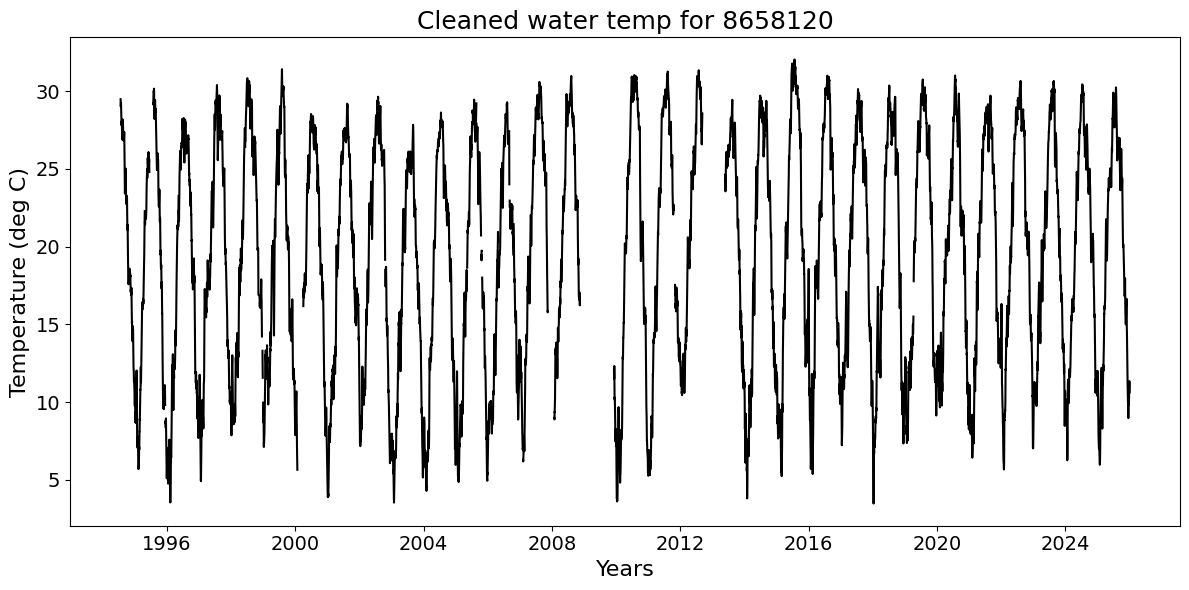

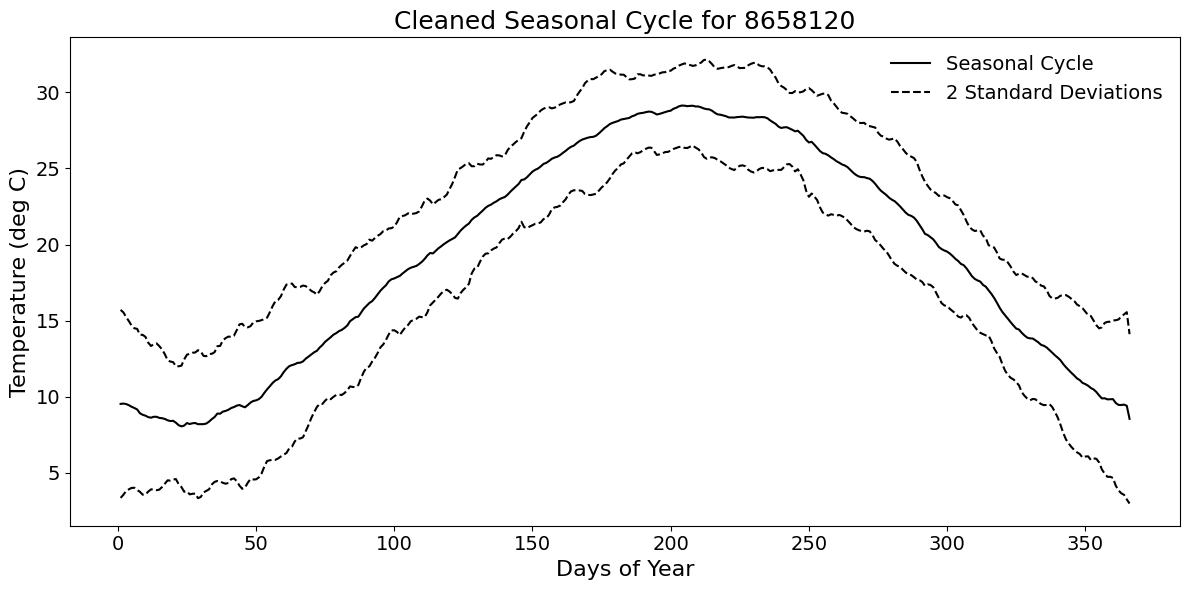

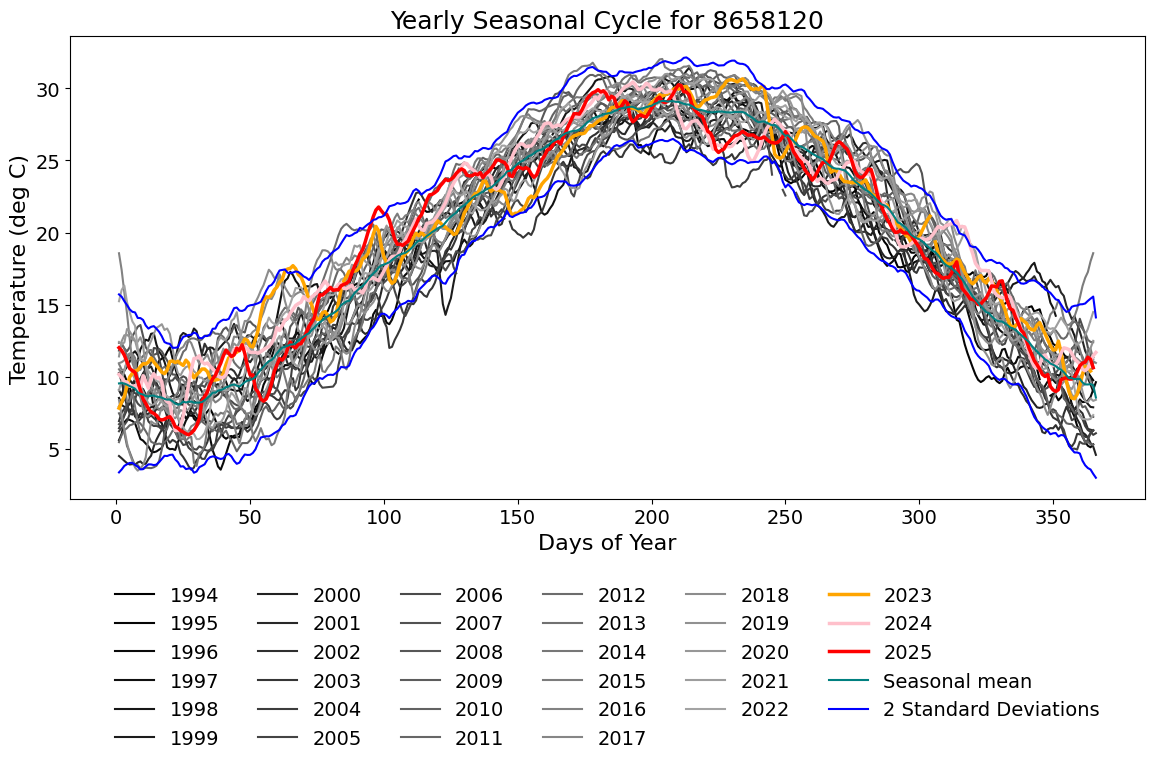

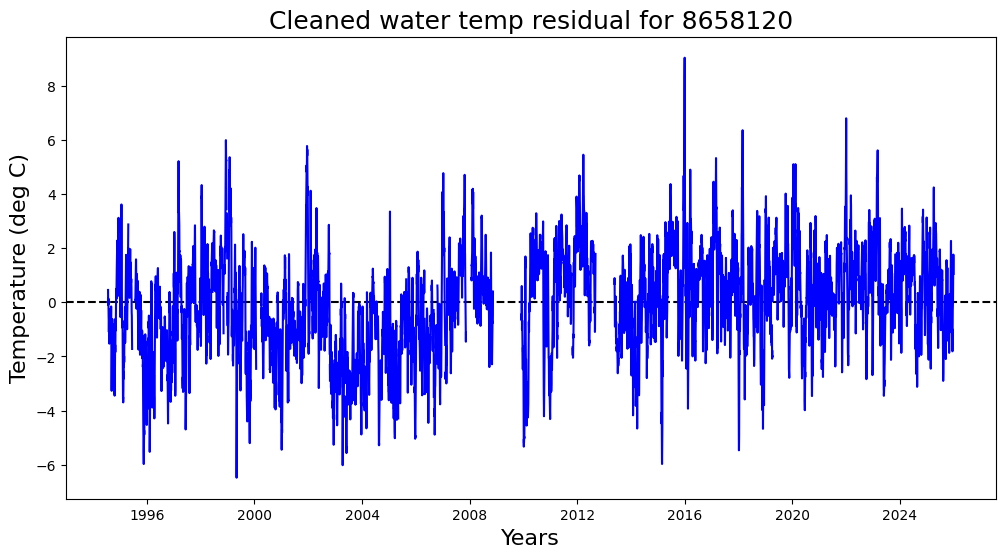

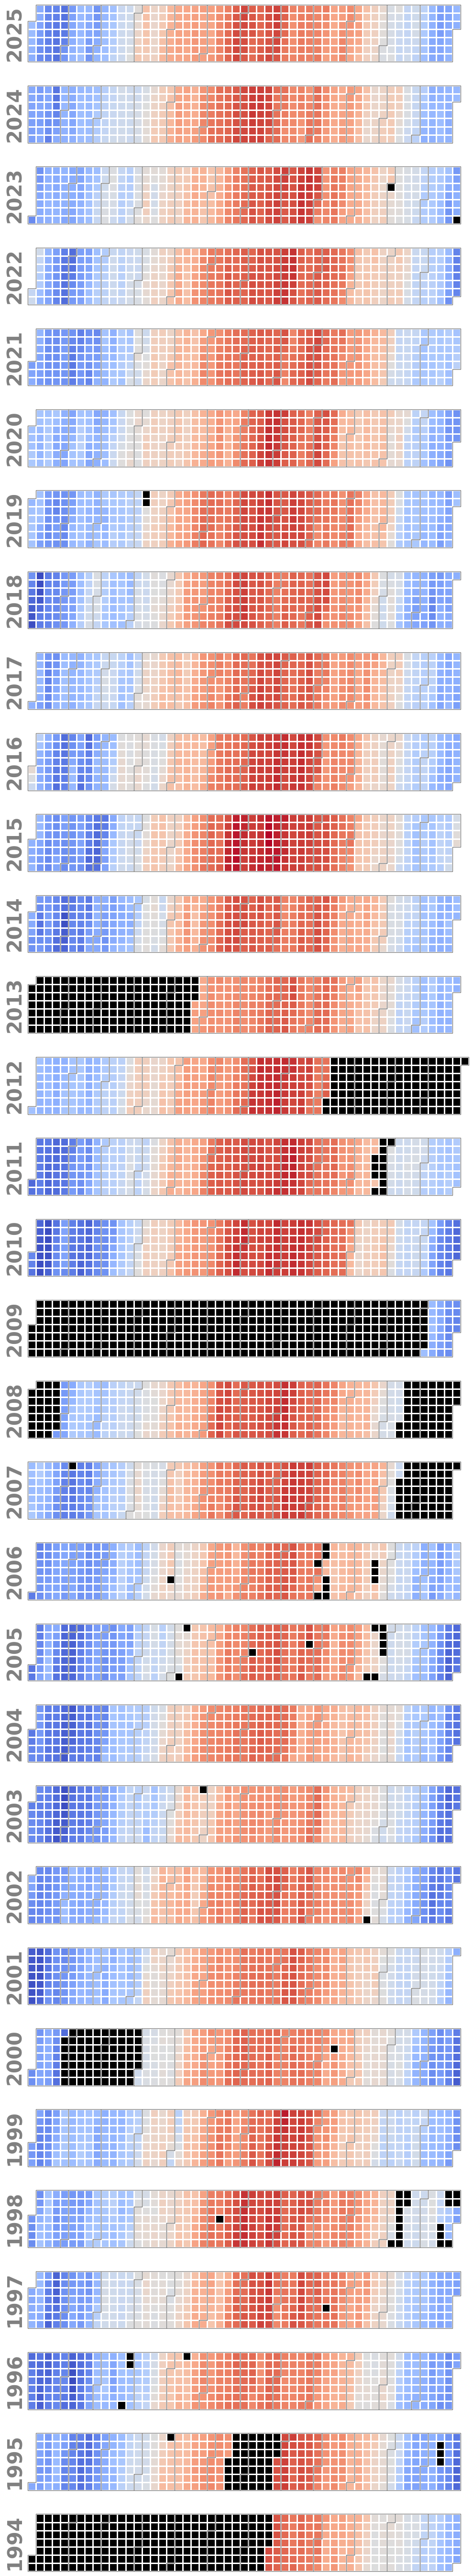

In [11]:
# @title Plot and save the graphics

# Choose station(s) and determine if plots should display
if station_choice == 'single':
    station_list = [station_selection]
    display_graphics = True
else:
    station_list = station_list
    display_graphics = False  # Suppress output when running all

# Process each station
for station in station_list:
    print(f"\nProcessing station: {station}")
    try:
        # Assuming 'path' is defined earlier in your notebook
        df = pd.read_csv(path + f"{station}_final_daily_flagged.csv")
    except FileNotFoundError:
        print(f"File not found for station {station}")
        continue

    # Ensure the Date column is treated as datetime for accurate matching
    df['Date'] = pd.to_datetime(df['Date'])

    cleaned_df = clean_station_data(df)
    
    # Extract the string classification safely
    classification_series = station_df.loc[station_df['Station ID'] == int(station), 'WT Data Classification']
    
    # Check if we actually found a classification before extracting
    if not classification_series.empty:
        classification = classification_series.iloc[0]
        print(f'This station has a {classification} data quality')
        
        if classification == 'Incomplete':
            print('This station is not currently suitable for any analysis outside of this notebook due to issues in its data quality.\nSee associated report for more details.')
    else:
        print("Warning: Station ID not found in station_df metadata.")

    # Generate the plots, passing our boolean display parameter
    plot_station_data(station, cleaned_df, show_plots=display_graphics)

## **Conclusions**

### Thank you for taking the time to walk through this Coastal Temperature Final Station Graphics Notebook
### This notebook is associated with the Evaluation and Quality Control of CO-OPS Coastal Water Temperature Data Technical Report and replicates some of the station-specific graphics available in the report with the QA/QCed daily water temperature data.

